In [5]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table

In [6]:
USER_ROOT = Path('/global/cfs/cdirs/desicollab/users/jchdj')
DATA_ROOT = USER_ROOT / 'desi-y3-hsc' / 'data'
DESI_ROOT = DATA_ROOT / 'desi' / 'cat'
HSC_ROOT = DATA_ROOT / 'hsc' / 'cat'
XMATCH_ROOT = DATA_ROOT / 'xmatch'

# Find the desi file
desi_file = Path(DESI_ROOT, 'desiy3_cut_cat.fits')
print(f'DESI sampled catalog : {desi_file}')

# Find HSC data
hsc_file = Path(HSC_ROOT, 'hscy3_cat.fits')
print(f'HSC catalog : {hsc_file}')

print(f'Saving cross-matched catalog to : {XMATCH_ROOT}')

DESI sampled catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits
HSC catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits
Saving cross-matched catalog to : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch


In [7]:
# Read the HSC catalog (ETA ~ 2s)
hsc = fio.read(hsc_file)
# Read the DESI catalog (ETA ~ 20-30s)
desi = fio.read(desi_file)

In [8]:
print(hsc.dtype.names)
print(desi.dtype.names)

('RA', 'Dec', 'object_id', 'e_1', 'e_2', 'e_rms', 'weight', 'm_corr', 'c_1', 'c_2', 'resolution', 'aperture_mag', 'z_bin', 'dnnz_photoz_best', 'dnnz_photoz_risk_best', 'dnnz_photoz_std_best', 'dnnz_photoz_err68_min', 'dnnz_photoz_err68_max', 'dnnz_photoz_err95_min', 'dnnz_photoz_err95_max', 'e1_psf', 'e2_psf')
('TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'RELEASE', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'MAIN_NSPEC', 'MAIN_PRIMARY', 'SV_NSPEC', 'SV_PRIMARY', 'ZCAT_NSPEC', 'ZCAT_PRIMARY')


In [9]:
# HSC galaxy coordinates
hsc_coords = SkyCoord(ra=hsc['RA']*u.deg, dec=hsc['Dec']*u.deg)

In [40]:
# Generate a MOC from HSC positions
n_order = 13
print(f'Spatial resolution of MOC : {MOC.order_to_spatial_resolution(n_order).to(u.arcsec):.3f}')
hsc_moc = MOC.from_skycoords(hsc_coords, max_norder=n_order)

Spatial resolution of MOC : 25.766 arcsec


In [41]:
# DESI galaxy coordinates
desi_coords = SkyCoord(ra=desi['TARGET_RA']*u.deg, dec=desi['TARGET_DEC']*u.deg)

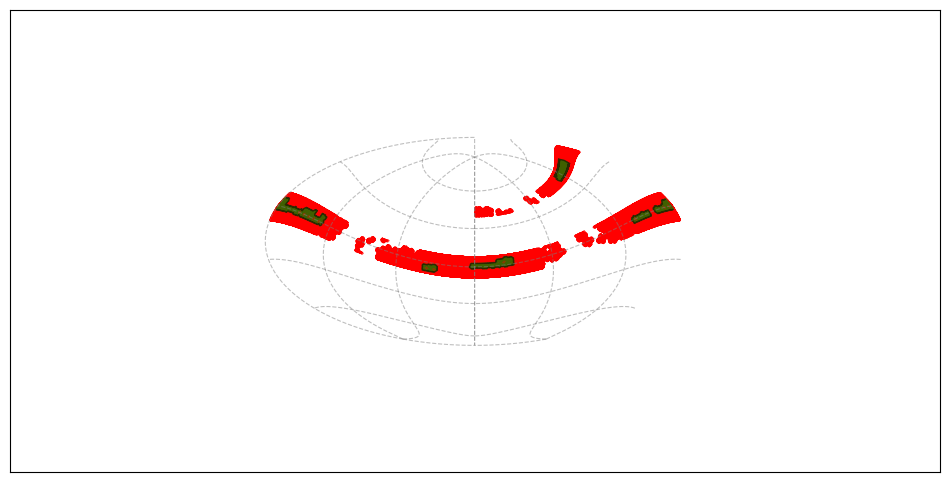

In [42]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=360 * u.deg,
           center=SkyCoord(0, 20, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT"
           ) as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
ax.scatter(
    desi_coords.ra.deg[0::10], 
    desi_coords.dec.deg[0::10],
    transform=ax.get_transform('world'),
    s=0.005, 
    color='red', 
    label='DESI targets'
    )
hsc_moc.fill(ax=ax, wcs=wcs, alpha=0.5, fill=True, color="green")
hsc_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="black")
ax.grid(color='gray', linestyle='--', alpha=0.5)

In [45]:
mask = hsc_moc.contains_skycoords(desi_coords, keep_inside=True)

In [46]:
print(f'DESI catalog size : {len(desi)}')
desi_masked = desi[np.flatnonzero(mask)]
print(f'DESI catalog size : {len(desi_masked)}')

DESI catalog size : 22971426
DESI catalog size : 3061959


In [47]:
desi_masked_coords = SkyCoord(ra=desi_masked['TARGET_RA']*u.deg, dec=desi_masked['TARGET_DEC']*u.deg)
print(f'Masked DESI catalog size : {len(desi_masked)}')

Masked DESI catalog size : 3061959


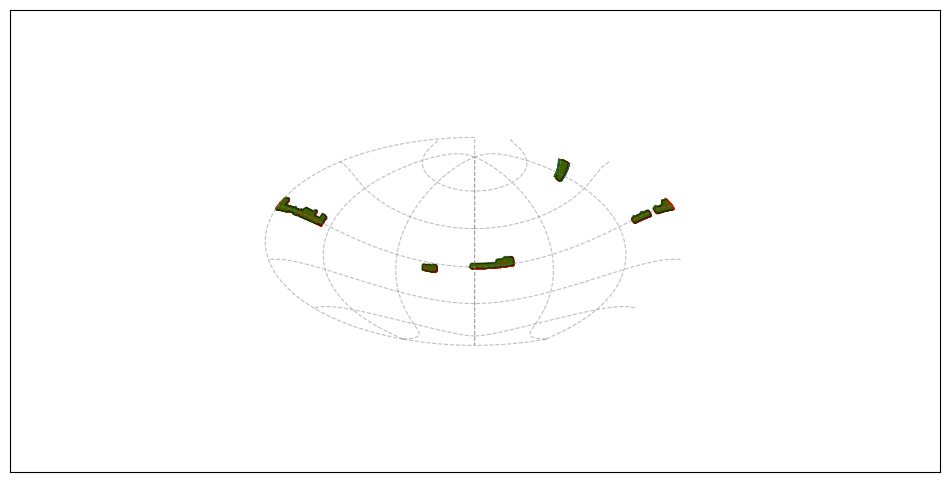

In [48]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=360 * u.deg,
           center=SkyCoord(0, 20, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
ax.scatter(
    desi_masked_coords.ra.deg[0::10], 
    desi_masked_coords.dec.deg[0::10],
    transform=ax.get_transform('world'),
    s=0.005, 
    color='red', 
    label='DESI targets'
    )
hsc_moc.fill(ax=ax, wcs=wcs, alpha=0.5, fill=True, color="green")
hsc_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="black")
ax.grid(color='gray', linestyle='--', alpha=0.5)

In [49]:
fio.write(XMATCH_ROOT / 'desi_hsc.fits', desi_masked, clobber=True)

In [ ]:
orders = np.arange(6, 18)
res = []
size = []
print(f'DESI catalog size : {len(desi)}')
for i in orders:
    print(i)
    res.append(MOC.order_to_spatial_resolution(i).to(u.arcsec))
    print(f'Spatial resolution of MOC : {res[-1]:.3f}')
    hsc_moc = MOC.from_skycoords(hsc_coords, max_norder=i)
    mask = hsc_moc.contains_skycoords(desi_coords, keep_inside=True)
    size.append(len(np.flatnonzero(mask)))
    print(f'DESI footprint catalog size : {size[-1]}')

plt.figure(figsize=(6, 4))
resolution = [r.value for r in res]
plt.plot(resolution, size, marker='o', color='blue')
for i in range(len(resolution)):
    plt.text(resolution[i], size[i]+1e5, str(orders[i]), ha='center', va='bottom')
plt.xlabel('Spatial resolution of HSC MOC (arcsec)')
plt.ylabel('DESI sources in HSC footprint')
plt.xscale('log')
plt.yscale('log')
plt.grid()